# Preparation

In [1]:
import plotting as P
from config import create_config
import tables
from IPython.display import display

config = create_config()
cache_dir = f"./cache_seed{config.seed}"
tables.save_config_table(config)
tables.show_spec(config, keys=["system", "seed", "n_states", "n_controls", "t1_initial"])

system,seed,n_states,n_controls,t1_initial
burgers,999,32,2,15.000000


# Data Generation

trajectories,data points,t (min),t (max),|x| (mean),|x| (max),||x|| (mean),||x|| (max)
10,1669,0.000000,4.252865,0.287727,1.397875,0.518691,1.026315


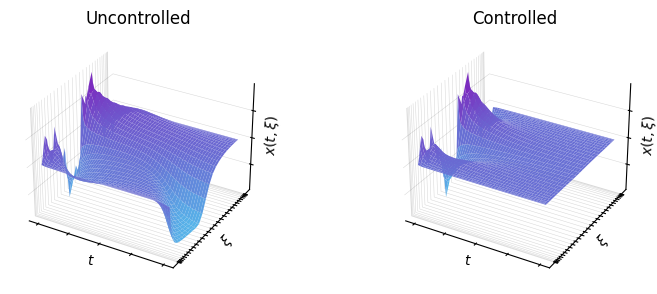

In [2]:
import matplotlib.pyplot as plt
from data import load_or_generate

# Load data - now returns train, val, meta
data_train, data_val, meta = load_or_generate(config, n_trajectories=10, controller=config.ocp.LQR)
data = data_train  # Keep using 'data' for backward compatibility

# 2. Save AND get the summary dataframe
summary_df = tables.save_data_summary_table(config, data)

# 3. Display it nicely in the notebook

display(summary_df.style.hide(axis="index"))


fig = P.plot_3d(config=config, controller=config.ocp.LQR, savepath="figures/test.pdf")
plt.show()

# Controller Training

In [3]:
from controls.model_factory import train_or_load_gradnet
from controls.train import TrainConfig

cfg = TrainConfig(batch_size=int(config.n_states)) # old: 1.0

# 1. Save to LaTeX using the new generic function
tables.save_params_table(cfg, "thesis/tables/traincfg.tex", title="Training Configuration")

# 2. Show in Notebook using the universal show_spec
tables.show_spec(
    cfg, 
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_lr", "batch_size", "grad_clip"], 
    title="Training Configuration"
)

**Training Configuration**

sup_epochs,sup_lr,unsup_epochs,unsup_lr,batch_size,grad_clip
1,0.000010,5,0.000500,32,None



Training: Hybrid GradQRNet (sup)

Training: Ad. GradQRNet (sup)


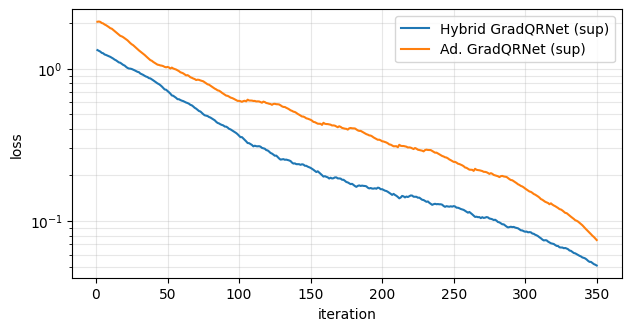

In [4]:
from controls.model_factory import train_controllers

# Train controllers (uses defaults from model_factory.py)
# To override defaults, pass controller_configs parameter, e.g.:
# controller_configs={"Model 3 (Hybrid)": {"enabled": True}}
trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  # Use training data
    val_data=data_val,  # NEW: Pass validation data
)

# Plot training losses
P.plot_training_losses(
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
    savepath="figures/loss_curve_all.pdf",
);

# Evaluation

In [5]:
controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]

In [6]:
from simulation import monte_carlo

# Use the controllers list defined in Cell 9
results = monte_carlo(config.ocp, config, controllers)
tables.show_monte_carlo_results(results)
tables.save_monte_carlo_results(results, config=config)

100%|██████████| 100/100 [00:23<00:00,  4.34it/s]


Controller,Stability (S),Final ||X|| (mean),t_conv (median),t_conv (mean),Cost J (median),Cost J (mean)
LQR (Baseline),82.0%,0.0039,12.29,12.86,0.4863,0.5535
Hybrid GradQRNet (sup),89.0%,0.0034,12.04,12.80,0.5195,0.5871
Ad. GradQRNet (sup),90.0%,0.0029,11.72,12.46,0.5348,0.6027


,Model,Stability $S$,$t_{\text{conv}}$ (mean),Cost $J$ (mean)
0,LQR (Baseline),0.82,12.855930,0.553525
1,Hybrid GradQRNet (sup),0.89,12.802226,0.587072
2,Ad. GradQRNet (sup),0.90,12.455644,0.602652


## Plots

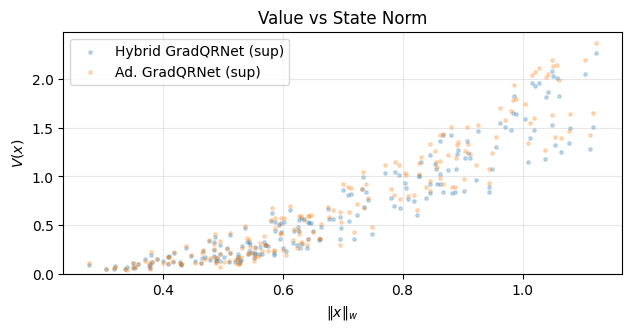

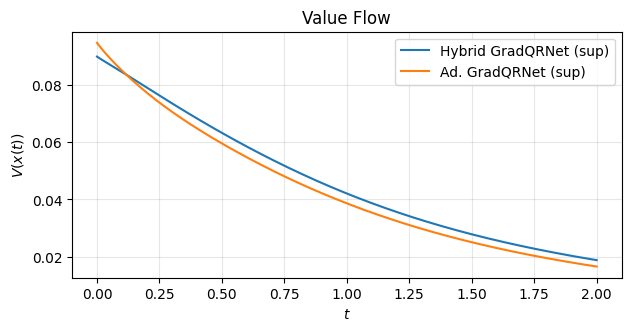

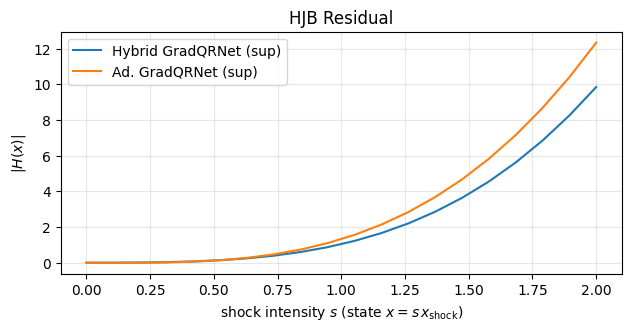

In [ ]:
P.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
    savepath="figures/combined_analysis.pdf"
)
plt.show()